# Exploratory Data Analysis

## Import Neccessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("clean_train.csv")

## SalePrice Distribution Chart

In [ ]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


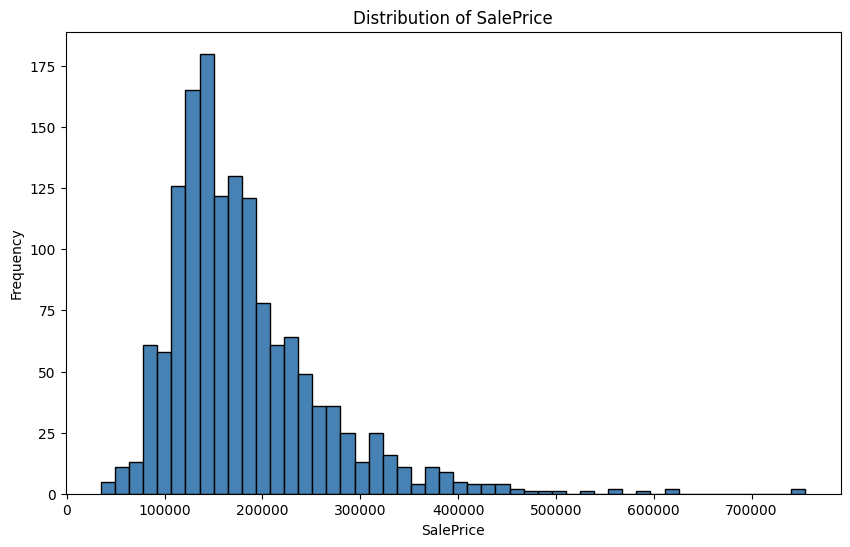

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

Most of the houses in the dataset are between the price range of 110000 USD and 190000 USD, with the highest number of houses being sold at around 145000 USD.

The lowest price is 34900 USD, and the highest is 755000 USD.

The distribution also shows a right skew (which was previously observed in Task 2 with the IQR) , with very few houses being sold at above 450000 USD.  

In [ ]:
correlation = df.corr(numeric_only = True)['SalePrice'].sort_values(ascending = False)

In [ ]:
print(correlation[:19])

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.334771
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
Name: SalePrice, dtype: float64


Text(0.5, 1.0, 'Features Most Correlated with SalePrice')

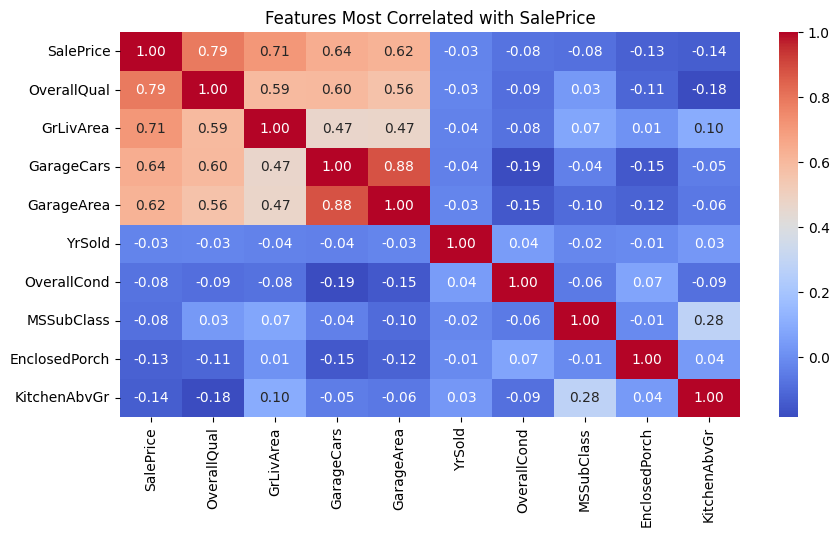

In [ ]:
top_positive = correlation.index[:5]
top_negative = correlation.index[-5:]
top_features = top_positive.append(top_negative)

plt.figure(figsize=(10, 5))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Features Most Correlated with SalePrice')

The column with the most positive correlation with SalePrice (and unsurprisingly so), is OverallQual (0.79). The column contains ratings from 1 to 10 of the overall material and finish of the house. Naturally, the higher the quality, the higher the price, which perfectly explains the positive correlation.

Other positive correlations are GrLivArea(0.71), GarageCars(0.64), and GarageArea(0..62), which describe the measurement of above grade (ground) living area in square feet, the size of garage in car capacity, and the size of garage in square feet respectively.

The column with the most negative correlation with SalePrice, is KitchenAbvGr (-0.14).

Other negative correlations are EnclosedPorch(-0.13), MSSubClass(-0.08), OverallCond(-0.08), and YrSold(-0.03), which describe the enclosed porch area in square feet, the type of dwelling involved in the sale, ratings of the overall condition of the house, and year sold respectively.

Although, it is important to note that these negative correlation are not below -0.3, making them all very weak correlations.

## Identifying Trends

Text(0, 0.5, 'SalePrice')

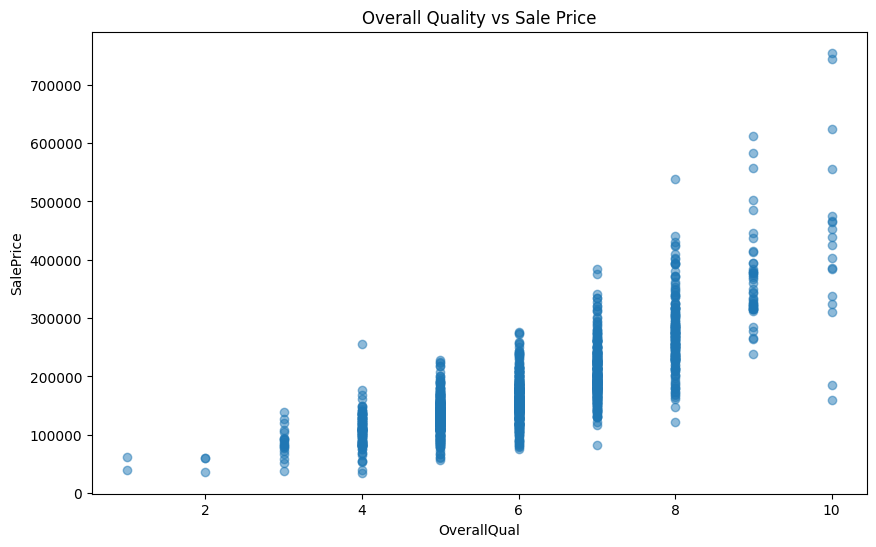

In [ ]:
plt.figure(figsize = (10, 6))
plt.scatter(df['OverallQual'], df['SalePrice'], alpha = 0.5)
plt.title("Overall Quality vs Sale Price")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")

The scatter plot confirms the strong positive correlation (0.79) between OverallQual and SalePrice. Houses with higher quality ratings consistently sell for more, with quality-10 homes reaching up to 750,000 USD. However, the wider spread at higher quality ratings suggests that other factors also influence the price of premium homes.

## In Summary

SalePrice is right-skewed with a median of 163,000 USD and most homes selling between 100,000 USD and 200,000 USD

OverallQual is the strongest predictor of SalePrice with a correlation of 0.79, followed by GrLivArea (0.71) and GarageCars (0.64)

Negative correlations in this dataset are generally weak, with KitchenAbvGr showing the strongest negative relationship at -0.14

Categorical columns were excluded from correlation analysis as they require encoding before numerical relationships can be measured. This is addressed in Task 5.